# qSimCells — Quantum Hardware Benchmark
**Four-condition comparison: Ideal sim · Noisy sim · Real HW raw · Real HW mitigated**

| Section | Content |
|---|---|
| 0 | IBM credentials (run once) |
| 1 | Configuration & paths |
| 2 | Imports, backend & circuits |
| 3 | Device calibration snapshot |
| 4 | Ideal AerSim + Noisy AerSim baselines |
| 5 | Real HW raw (fresh job submission) |
| 6 | Real HW mitigated: DD/XY4 + twirling + TREX |
| 7 | Master figure (panels A-D) |
| 8 | Load existing simulated AnnData |
| 9 | Build AnnData from hardware shots |
| 10 | Side-by-side UMAP |
| 11 | Export: regenerate device h5ad + JSON report |

> `RUN_ON="local"` runs the full pipeline against FakeMarrakesh (no credits, instant).  
> `RUN_ON="real"` submits jobs to IBM Marrakesh. Set this only for the actual hardware run.


## 0 · IBM Credentials  *(run once, then skip)*

In [1]:
IBM_TOKEN    = "paste_your_token_here"
IBM_INSTANCE = "paste_your_instance_crn_here"

# Uncomment, run ONCE, then recomment.
# from qiskit_ibm_runtime import QiskitRuntimeService
# QiskitRuntimeService.save_account(
#     channel="ibm_quantum_platform", token=IBM_TOKEN,
#     instance=IBM_INSTANCE, overwrite=True, set_as_default=True)
# print("Credentials saved.")


## 1 · Configuration & Paths

In [17]:
import numpy as np
from pathlib import Path

RUN_ON        = "real"          # "local" = FakeMarrakesh  |  "real" = IBM Marrakesh (ibm_marrakesh)
BACKEND_NAME  = "ibm_marrakesh"
MY_SEED       = 42
TRANSPILE_OPT = 3

DATA_DIR  = Path("../")
SIM_H5AD  = DATA_DIR / "sim_merged_datasets_co_mo_quantum_simulated.h5ad"
DEV_H5AD  = DATA_DIR / "sim_merged_datasets_co_mo_quantum_device_hist_corr.h5ad"

print("Simulated h5ad:", SIM_H5AD, "| exists:", SIM_H5AD.exists())
print("Device h5ad   :", DEV_H5AD,  "| exists:", DEV_H5AD.exists())

# ── qSimCells params (must match qSim_cell_chat.ipynb) ───────────────────────
ANG_CT1        = np.array([0.2, 0.1, 0.4, 0.9, 0.8]) * np.pi
ANG_CT2        = np.array([0.2, 0.3, 0.2, 0.7, 0.5]) * np.pi
INTERACTION_CO = [(3, 5), (5, 7), (7, 0)]
INTERACTION_MO = [(2, 1)]
N_GENES        = 10
GENE_NAMES     = [f"g{i}" for i in range(N_GENES)]
N_SHOTS        = 2000

MU_V   = np.array([5.] * 5);  R_V   = np.array([1.] * 5)
N_HKG  = 50;  MU_HKG = np.full(N_HKG, 80.);  R_HKG = np.full(N_HKG, 6.)

SIM_SHOTS       = 32_768
NOISE_SIM_SHOTS = 8_192
RAW_SHOTS       = 4_096
NUM_RANDS       = 200
SHOTS_PER_RAND  = 20


Simulated h5ad: ..\sim_merged_datasets_co_mo_quantum_simulated.h5ad | exists: True
Device h5ad   : ..\sim_merged_datasets_co_mo_quantum_device_hist_corr.h5ad | exists: False


## 2 · Imports, Backend & Circuits

In [18]:
import json, datetime, warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import matplotlib.gridspec as mgrid
from matplotlib.colors import Normalize
import networkx as nx
import pandas as pd
import anndata as ad
import scanpy as sc
from scipy.stats import spearmanr
import scipy.sparse as sp

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel

np.random.seed(MY_SEED)
sc.settings.verbosity = 0

if RUN_ON == "local":
    from qiskit_ibm_runtime.fake_provider import FakeMarrakesh
    backend = FakeMarrakesh();  service = None
    print("Mode: LOCAL  |  backend:", backend.name)
    print("NOTE: calibration data is a frozen Feb-2025 FakeMarrakesh snapshot.")
else:
    from qiskit_ibm_runtime import QiskitRuntimeService
    service  = QiskitRuntimeService()
    backend  = service.backend(BACKEND_NAME)
    print(f"Mode: REAL  |  backend: {backend.name}  |  qubits: {backend.num_qubits}")


Mode: REAL  |  backend: ibm_marrakesh  |  qubits: 156


In [19]:
def build_circuit(ang_ct1, ang_ct2, interactions):
    ang = np.concatenate([ang_ct1, ang_ct2])
    qr  = QuantumRegister(len(ang), "q")
    c1  = ClassicalRegister(5, "c1"); c2 = ClassicalRegister(5, "c2")
    qc  = QuantumCircuit(qr, c1, c2)
    for i,a in enumerate(ang): qc.ry(a, qr[i])
    for a,b in interactions:   qc.crx(np.pi, qr[a], qr[b])
    qc.measure(qr[:5], c1);   qc.measure(qr[5:], c2)
    return qc

qc_co = build_circuit(ANG_CT1, ANG_CT2, INTERACTION_CO)
qc_mo = build_circuit(ANG_CT1, ANG_CT2, INTERACTION_MO)

pm     = generate_preset_pass_manager(backend=backend, optimization_level=TRANSPILE_OPT,
                                      seed_transpiler=MY_SEED)
isa_co = pm.run(qc_co); isa_mo = pm.run(qc_mo)

layout_co = isa_co.layout.final_index_layout(filter_ancillas=True)
layout_mo = isa_mo.layout.final_index_layout(filter_ancillas=True)
gmap_co   = {g: layout_co[g] for g in range(N_GENES)}
gmap_mo   = {g: layout_mo[g] for g in range(N_GENES)}
twoq_gates = ("cx", "ecr", "cz")
print("Co gene->qubit:", gmap_co)
print("Mo gene->qubit:", gmap_mo)


Co gene->qubit: {0: 27, 1: 54, 2: 14, 3: 8, 4: 147, 5: 7, 6: 134, 7: 17, 8: 0, 9: 2}
Mo gene->qubit: {0: 54, 1: 147, 2: 148, 3: 14, 4: 134, 5: 0, 6: 7, 7: 2, 8: 8, 9: 19}


## 3 · Device Calibration Snapshot

IBM quantum computers are continuously monitored and daily-benchmarked to track parameter
drift from TLS fluctuations, ambient temperature, and control instability. Error rates here
reflect the **calibration state at run time** and are stored in the JSON report for full
reproducibility.


In [20]:
target = backend.target
TWO_Q_GATE = next((g for g in ("ecr","cx","cz") if g in target), "cx")

if RUN_ON == "local":
    try:    _snap = str(backend.properties().last_update_date)
    except: _snap = "unknown"
    cal_date = f"{_snap} [LOCAL - FakeMarrakesh, NOT real device]"
    print("WARNING: LOCAL MODE - data below is from FakeMarrakesh (frozen Feb 2025).")
    print("         Set RUN_ON='real' before the real hardware run.")
else:
    try:    cal_date = str(backend.properties().last_update_date)
    except: cal_date = str(datetime.datetime.utcnow().date()) + " (live, date unavailable)"

print(f"Backend          : {backend.name}")
print(f"Last calibration : {cal_date}")
print(f"Native 2Q gate   : {TWO_Q_GATE}")

ro_err, sx_err, t1_us, t2_us = {}, {}, {}, {}
for q in range(backend.num_qubits):
    qp = (target.qubit_properties or [None]*backend.num_qubits)[q]
    m  = target["measure"].get((q,)) if "measure" in target else None
    ro_err[q] = (m.error or 0.0) if m else 0.0
    for sx in ("sx","x"):
        p = target[sx].get((q,)) if sx in target else None
        if p is not None: sx_err[q] = p.error or 0.0; break
    else: sx_err[q] = 0.0
    t1_us[q] = qp.t1*1e6 if (qp and qp.t1) else float("nan")
    t2_us[q] = qp.t2*1e6 if (qp and qp.t2) else float("nan")

twoq_err = {}
for qargs,props in target[TWO_Q_GATE].items():
    if qargs and len(qargs)==2 and props is not None:
        twoq_err[qargs] = props.error or 0.0

print(f"\nDevice-wide medians:")
print(f"  T1       : {np.nanmedian(list(t1_us.values())):.0f} us")
print(f"  T2       : {np.nanmedian(list(t2_us.values())):.0f} us")
print(f"  Readout  : {np.nanmedian(list(ro_err.values()))*100:.3f} %")
print(f"  sx/X     : {np.nanmedian(list(sx_err.values()))*100:.4f} %")
print(f"  {TWO_Q_GATE:3s}      : {np.nanmedian(list(twoq_err.values()))*100:.3f} %")


Backend          : ibm_marrakesh
Last calibration : 2026-07-15 08:20:49-05:00
Native 2Q gate   : cz

Device-wide medians:
  T1       : 149 us
  T2       : 82 us
  Readout  : 1.038 %
  sx/X     : 0.0326 %
  cz       : 0.286 %


In [21]:
def gene_error_table(gmap, label):
    rows = []
    for g,q in gmap.items():
        pairs = [(q,q2) for (q1,q2) in twoq_err if q1==q] + \
                [(q1,q) for (q1,q2) in twoq_err if q2==q]
        best_2q = min((twoq_err.get(p,float("nan")) for p in pairs), default=float("nan"))
        rows.append({"gene":f"g{g}","phys_q":q,
                     "T1_us":round(t1_us[q],1),"T2_us":round(t2_us[q],1),
                     "readout_%":round(ro_err[q]*100,3),"sx_%":round(sx_err[q]*100,4),
                     f"{TWO_Q_GATE}_%":round(best_2q*100,3) if not np.isnan(best_2q) else "---"})
    df = pd.DataFrame(rows).set_index("gene")
    print(f"\n-- {label} --"); print(df.to_string())
    return df

df_co_err = gene_error_table(gmap_co, "Co qubit errors")
df_mo_err = gene_error_table(gmap_mo, "Mo qubit errors")

print("\n-- CRX interaction-pair errors --")
for lbl,interactions,gmap in [("Co",INTERACTION_CO,gmap_co),("Mo",INTERACTION_MO,gmap_mo)]:
    for (ga,gb) in interactions:
        qa,qb = gmap[ga],gmap[gb]
        err = twoq_err.get((qa,qb), twoq_err.get((qb,qa),float("nan")))
        tag = f"{err*100:.3f}%" if not np.isnan(err) else "SWAP-routed (no direct edge)"
        print(f"  [{lbl}] g{ga}(q{qa})->g{gb}(q{qb}): {tag}")



-- Co qubit errors --
      phys_q  T1_us  T2_us  readout_%    sx_%   cz_%
gene                                                
g0        27  151.9  178.9      0.562  0.0294  0.193
g1        54  262.2   78.6      0.183  0.0211  0.128
g2        14  343.5  104.3      0.293  0.0095  0.156
g3         8  193.5   95.2      0.391  0.0244  0.209
g4       147  262.6   88.3      0.317  0.0248  0.192
g5         7  183.8  170.0      0.354  0.0175  0.146
g6       134  213.9  134.3      0.305  0.0304  0.131
g7        17  191.7   11.3      0.488  0.0427  0.160
g8         0  249.9   34.2      0.317  0.0295  0.286
g9         2  292.6  360.5      0.378  0.0177  0.156

-- Mo qubit errors --
      phys_q  T1_us  T2_us  readout_%    sx_%   cz_%
gene                                                
g0        54  262.2   78.6      0.183  0.0211  0.128
g1       147  262.6   88.3      0.317  0.0248  0.192
g2       148  150.8   46.0      0.427  0.0256  0.152
g3        14  343.5  104.3      0.293  0.0095  0.156


## 4 · Ideal AerSim + Noisy AerSim Baselines

**Ideal (noiseless):** gold standard reference — theoretical Born-rule probabilities.  
**Noisy:** same circuit through `NoiseModel.from_backend(backend)` — shows how well IBM's
noise model predicts the real device (compare to Section 5 raw results to check alignment).


In [22]:
def counts_to_probs(counts, n_genes=10):
    """AerSim get_counts() with two ClassicalRegisters -> per-gene P(1)."""
    total = sum(counts.values()); probs = np.zeros(n_genes)
    for bs,cnt in counts.items():
        parts = bs.strip().split()
        c2_str,c1_str = (parts[0],parts[1]) if len(parts)==2 \
                         else (bs.zfill(n_genes)[:5],bs.zfill(n_genes)[5:])
        for g in range(5):
            probs[g]   += int(c1_str[-(g+1)])*cnt
            probs[5+g] += int(c2_str[-(g+1)])*cnt
    probs /= total
    return probs, np.sqrt(probs*(1-probs)/total)

from qiskit import transpile as qk_transpile
def aer_counts(qc, shots, noise_model=None):
    sim = AerSimulator(noise_model=noise_model) if noise_model else AerSimulator()
    isa = qk_transpile(qc, sim, seed_transpiler=MY_SEED)
    return sim.run(isa, shots=shots, seed_simulator=MY_SEED).result().get_counts()

p_ideal_co, e_ideal_co = counts_to_probs(aer_counts(qc_co, SIM_SHOTS))
p_ideal_mo, e_ideal_mo = counts_to_probs(aer_counts(qc_mo, SIM_SHOTS))

noise_model = NoiseModel.from_backend(backend)
p_noisy_co, e_noisy_co = counts_to_probs(aer_counts(qc_co, NOISE_SIM_SHOTS, noise_model))
p_noisy_mo, e_noisy_mo = counts_to_probs(aer_counts(qc_mo, NOISE_SIM_SHOTS, noise_model))

print("Ideal Co  P(g=1):", np.round(p_ideal_co, 3))
print("Noisy Co  P(g=1):", np.round(p_noisy_co, 3))


Ideal Co  P(g=1): [0.749 0.025 0.346 0.976 0.905 0.884 0.204 0.808 0.793 0.501]
Noisy Co  P(g=1): [0.743 0.032 0.356 0.971 0.898 0.882 0.21  0.805 0.788 0.507]


## 5 · Real HW — Raw  *(submit fresh jobs)*

No error mitigation — shows the bare device floor.  
Job IDs are printed below. Paste them into the retrieval cell if you restart the kernel.


In [23]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

def sampler_to_probs(pub_result, n_genes=10):
    """SamplerV2 BitArray -> per-gene P(1)."""
    c1c = pub_result.data.c1.get_counts()
    c2c = pub_result.data.c2.get_counts()
    total = sum(c1c.values()); probs = np.zeros(n_genes)
    for bs,cnt in c1c.items():
        bs = bs.zfill(5)
        for g in range(5): probs[g]   += int(bs[4-g])*cnt
    for bs,cnt in c2c.items():
        bs = bs.zfill(5)
        for g in range(5): probs[5+g] += int(bs[4-g])*cnt
    probs /= total
    return probs, np.sqrt(probs*(1-probs)/total)

def sampler_to_binary_matrix(pub_result):
    """Per-shot binary matrices for CT1 (genes 0-4) and CT2 (genes 5-9)."""
    try:
        c1s = pub_result.data.c1.get_bitstrings()
        c2s = pub_result.data.c2.get_bitstrings()
        n = len(c1s)
        b1 = np.zeros((n,5),dtype=int); b2 = np.zeros((n,5),dtype=int)
        for i,(s1,s2) in enumerate(zip(c1s,c2s)):
            s1=s1.zfill(5); s2=s2.zfill(5)
            for g in range(5): b1[i,g]=int(s1[4-g]); b2[i,g]=int(s2[4-g])
    except AttributeError:
        c1c = pub_result.data.c1.get_counts()
        c2c = pub_result.data.c2.get_counts()
        n = sum(c1c.values())
        b1 = np.zeros((n,5),dtype=int); b2 = np.zeros((n,5),dtype=int)
        idx=0
        for bs,cnt in c1c.items():
            bs=bs.zfill(5)
            for _ in range(cnt): b1[idx]=[int(bs[4-g]) for g in range(5)]; idx+=1
        idx=0
        for bs,cnt in c2c.items():
            bs=bs.zfill(5)
            for _ in range(cnt): b2[idx]=[int(bs[4-g]) for g in range(5)]; idx+=1
    return b1, b2


In [9]:
# ── Submit raw jobs ───────────────────────────────────────────────────────────
# NOTE: SamplerV2 uses mode= (not backend=) since qiskit-ibm-runtime 0.20+
sampler_raw = Sampler(mode=backend)
sampler_raw.options.default_shots = RAW_SHOTS

job_raw_co = sampler_raw.run([isa_co])
job_raw_mo = sampler_raw.run([isa_mo])
print("Raw Co job ID:", job_raw_co.job_id())
print("Raw Mo job ID:", job_raw_mo.job_id())
print("Paste these IDs into the retrieval cell below before any kernel restart.")


Raw Co job ID: d9btl2c1osis73bj4jg0
Raw Mo job ID: d9btl2k1osis73bj4jh0
Paste these IDs into the retrieval cell below before any kernel restart.


In [26]:
# ── Job status check ──────────────────────────────────────────────────────────
job_ids = {
    "RAW Co": "d8o3s4r2d42s73cejmgg",
    "RAW Mo": "d8o3s53qv2lc7389jb20",
}

for label, jid in job_ids.items():
    j = service.job(jid)
    print(f"{label}  |  status: {j.status()}  |  id: {jid}")

RAW Co  |  status: DONE  |  id: d8o3s4r2d42s73cejmgg
RAW Mo  |  status: DONE  |  id: d8o3s53qv2lc7389jb20


In [27]:
# ── Retrieve raw results (paste job IDs here if restarting kernel) ────────────
RAW_CO_JOB_ID = "d8o3s4r2d42s73cejmgg"
RAW_MO_JOB_ID = "d8o3s53qv2lc7389jb20"
job_raw_co = service.job(RAW_CO_JOB_ID)
job_raw_mo = service.job(RAW_MO_JOB_ID)

result_raw_co = job_raw_co.result()
result_raw_mo = job_raw_mo.result()
p_raw_co, e_raw_co = sampler_to_probs(result_raw_co[0])
p_raw_mo, e_raw_mo = sampler_to_probs(result_raw_mo[0])
print("Raw Co P(g=1):", np.round(p_raw_co, 3))
print("Raw Mo P(g=1):", np.round(p_raw_mo, 3))


Raw Co P(g=1): [0.739 0.021 0.331 0.97  0.897 0.886 0.212 0.808 0.774 0.496]
Raw Mo P(g=1): [0.094 0.344 0.335 0.974 0.889 0.094 0.22  0.099 0.784 0.499]


## 6 · Real HW — Mitigated (DD/XY4 + Gate Twirling + TREX)

All three available natively via `SamplerV2.options` — no EstimatorV2 needed:

| Technique | What it does |
|---|---|
| **DD/XY4** | Dynamical decoupling — suppresses idle-qubit dephasing |
| **Gate twirling** | Pauli-twirls 2Q gates — converts coherent errors to depolarising |
| **TREX** | Twirled Readout Error eXtinction — corrects readout misclassification |


In [29]:
# NOTE: SamplerV2 uses mode= (not backend=) since qiskit-ibm-runtime 0.20+
sampler_mit = Sampler(mode=backend)
sampler_mit.options.dynamical_decoupling.enable        = True
sampler_mit.options.dynamical_decoupling.sequence_type = "XY4"
sampler_mit.options.twirling.enable_gates              = True
sampler_mit.options.twirling.enable_measure            = True   # TREX
sampler_mit.options.twirling.num_randomizations        = NUM_RANDS
sampler_mit.options.twirling.shots_per_randomization   = SHOTS_PER_RAND

job_mit_co = sampler_mit.run([isa_co])
job_mit_mo = sampler_mit.run([isa_mo])
print("Mitigated Co job ID:", job_mit_co.job_id())
print("Mitigated Mo job ID:", job_mit_mo.job_id())
print("Paste these IDs into the retrieval cell below before any kernel restart.")


Mitigated Co job ID: d9bv1svngvls73a8phd0
Mitigated Mo job ID: d9bv1tfngvls73a8phe0
Paste these IDs into the retrieval cell below before any kernel restart.


In [30]:
# ── Job status check ──────────────────────────────────────────────────────────
job_ids = {
    "RAW Co": "d8o3sdj2d42s73cejmq0",
    "RAW Mo": "d8o3sdrnn5bs738vbpug",
}

for label, jid in job_ids.items():
    j = service.job(jid)
    print(f"{label}  |  status: {j.status()}  |  id: {jid}")

RAW Co  |  status: DONE  |  id: d8o3sdj2d42s73cejmq0
RAW Mo  |  status: DONE  |  id: d8o3sdrnn5bs738vbpug


In [31]:
# ── Retrieve mitigated results (paste job IDs here if restarting kernel) ──────
MIT_CO_JOB_ID = "d8o3sdj2d42s73cejmq0"
MIT_MO_JOB_ID = "d8o3sdrnn5bs738vbpug"
job_mit_co = service.job(MIT_CO_JOB_ID)
job_mit_mo = service.job(MIT_MO_JOB_ID)

result_mit_co = job_mit_co.result()
result_mit_mo = job_mit_mo.result()
p_mit_co, e_mit_co = sampler_to_probs(result_mit_co[0])
p_mit_mo, e_mit_mo = sampler_to_probs(result_mit_mo[0])
print("Mitigated Co P(g=1):", np.round(p_mit_co, 3))
print("Mitigated Mo P(g=1):", np.round(p_mit_mo, 3))


Mitigated Co P(g=1): [0.743 0.034 0.34  0.97  0.891 0.864 0.212 0.796 0.782 0.502]
Mitigated Mo P(g=1): [0.1   0.351 0.344 0.972 0.902 0.095 0.211 0.104 0.797 0.505]


## 7 · Master Figure (Panels A-D)

- **A** — Device topology with calibration error overlay
- **B** — Per-gene P(1): all 4 conditions side-by-side (Co top, Mo bottom)
- **C** — Per-qubit error heatmap (readout / sx / 2Q)
- **D** — Spearman rho + RMSE vs Ideal AerSim


In [32]:
CONDITIONS = {
    "Ideal AerSim"     : {"co":(p_ideal_co,e_ideal_co), "mo":(p_ideal_mo,e_ideal_mo), "color":"#2166AC"},
    "Noisy AerSim"     : {"co":(p_noisy_co,e_noisy_co), "mo":(p_noisy_mo,e_noisy_mo), "color":"#F4A582"},
    "Real HW raw"      : {"co":(p_raw_co,  e_raw_co),   "mo":(p_raw_mo,  e_raw_mo),   "color":"#D6604D"},
    "Real HW mitigated": {"co":(p_mit_co,  e_mit_co),   "mo":(p_mit_mo,  e_mit_mo),   "color":"#1A9850"},
}
cond_names = list(CONDITIONS.keys())
n_cond = len(cond_names)

rho_co, rho_mo, rmse_co, rmse_mo = [], [], [], []
for name in cond_names:
    pc, pm = CONDITIONS[name]["co"][0], CONDITIONS[name]["mo"][0]
    rho_co.append(spearmanr(p_ideal_co, pc).statistic)
    rho_mo.append(spearmanr(p_ideal_mo, pm).statistic)
    rmse_co.append(np.sqrt(np.mean((p_ideal_co - pc)**2)))
    rmse_mo.append(np.sqrt(np.mean((p_ideal_mo - pm)**2)))

print("Spearman rho (Co):", dict(zip(cond_names, [f"{r:.3f}" for r in rho_co])))
print("Spearman rho (Mo):", dict(zip(cond_names, [f"{r:.3f}" for r in rho_mo])))
print("RMSE        (Co):", dict(zip(cond_names, [f"{r:.4f}" for r in rmse_co])))
print("RMSE        (Mo):", dict(zip(cond_names, [f"{r:.4f}" for r in rmse_mo])))


Spearman rho (Co): {'Ideal AerSim': '1.000', 'Noisy AerSim': '1.000', 'Real HW raw': '1.000', 'Real HW mitigated': '1.000'}
Spearman rho (Mo): {'Ideal AerSim': '1.000', 'Noisy AerSim': '1.000', 'Real HW raw': '0.964', 'Real HW mitigated': '0.952'}
RMSE        (Co): {'Ideal AerSim': '0.0000', 'Noisy AerSim': '0.0061', 'Real HW raw': '0.0095', 'Real HW mitigated': '0.0105'}
RMSE        (Mo): {'Ideal AerSim': '0.0000', 'Noisy AerSim': '0.0053', 'Real HW raw': '0.0087', 'Real HW mitigated': '0.0048'}


## 7b · Joint Histogram Spearman (full 2\u00b9\u2070 distribution)

Computes Spearman rho between the **full joint probability distribution** over all
2\u00b9\u2070 = 1024 measurement outcomes and the ideal AerSim reference.
This validates that the entanglement-mediated co-expression structure
(not only per-gene marginals) is preserved across conditions.


In [33]:
# ─────────────────────────────────────────────────────────────────────────────
# JOINT HISTOGRAM SPEARMAN  (full 2^10 distribution, not just per-gene marginals)
# Each of the 2^10 = 1024 joint measurement outcomes gets its own probability
# mass; Spearman is then computed on these 1024-dim vectors vs ideal AerSim.
# ─────────────────────────────────────────────────────────────────────────────

def aer_joint_probs(counts_dict, n_genes=10):
    """AerSim counts dict (two ClassicalRegisters, 'c2_bits c1_bits')
    -> normalised probability vector over all 2^n_genes joint outcomes.
    Key encoding: c1_str (CT1, genes 0-4) concatenated with c2_str (CT2, genes 5-9)."""
    total = sum(counts_dict.values())
    joint = {}
    for bs, cnt in counts_dict.items():
        parts = bs.strip().split()
        if len(parts) == 2:
            c2_str, c1_str = parts[0], parts[1]
        else:
            full = bs.zfill(n_genes)
            c2_str, c1_str = full[:n_genes//2], full[n_genes//2:]
        key = c1_str.zfill(5) + c2_str.zfill(5)
        joint[key] = joint.get(key, 0) + cnt
    all_keys = [format(i, f'0{n_genes}b') for i in range(2**n_genes)]
    return np.array([joint.get(k, 0) / total for k in all_keys])


def sampler_joint_probs(pub_result, n_genes=10):
    """SamplerV2 BitArray (two ClassicalRegisters c1, c2)
    -> normalised probability vector over all 2^n_genes joint outcomes.
    Uses per-shot bitstrings so that CT1 and CT2 outcomes are paired correctly."""
    c1s = pub_result.data.c1.get_bitstrings()
    c2s = pub_result.data.c2.get_bitstrings()
    joint = {}
    for s1, s2 in zip(c1s, c2s):
        key = s1.zfill(5) + s2.zfill(5)
        joint[key] = joint.get(key, 0) + 1
    total = len(c1s)
    all_keys = [format(i, f'0{n_genes}b') for i in range(2**n_genes)]
    return np.array([joint.get(k, 0) / total for k in all_keys])


# Re-run ideal and noisy (seeded, deterministic) to obtain full counts objects
_counts_ideal_co = aer_counts(qc_co, SIM_SHOTS)
_counts_ideal_mo = aer_counts(qc_mo, SIM_SHOTS)
_counts_noisy_co = aer_counts(qc_co, NOISE_SIM_SHOTS, noise_model)
_counts_noisy_mo = aer_counts(qc_mo, NOISE_SIM_SHOTS, noise_model)

jp_ideal_co = aer_joint_probs(_counts_ideal_co)
jp_ideal_mo = aer_joint_probs(_counts_ideal_mo)
jp_noisy_co = aer_joint_probs(_counts_noisy_co)
jp_noisy_mo = aer_joint_probs(_counts_noisy_mo)
jp_raw_co   = sampler_joint_probs(result_raw_co[0])
jp_raw_mo   = sampler_joint_probs(result_raw_mo[0])
jp_mit_co   = sampler_joint_probs(result_mit_co[0])
jp_mit_mo   = sampler_joint_probs(result_mit_mo[0])

JOINT_DATA = {
    "Ideal AerSim"     : (jp_ideal_co, jp_ideal_mo),
    "Noisy AerSim"     : (jp_noisy_co, jp_noisy_mo),
    "Real HW raw"      : (jp_raw_co,   jp_raw_mo),
    "Real HW mitigated": (jp_mit_co,   jp_mit_mo),
}

rho_joint_co, rho_joint_mo = [], []
for name in cond_names:
    jco, jmo = JOINT_DATA[name]
    rho_joint_co.append(spearmanr(jp_ideal_co, jco).statistic)
    rho_joint_mo.append(spearmanr(jp_ideal_mo, jmo).statistic)

print("Joint histogram Spearman rho (Co)  [2^10 outcomes vs Ideal AerSim]:")
for name, r in zip(cond_names, rho_joint_co):
    print(f"  {name:25s}: {r:.4f}")
print()
print("Joint histogram Spearman rho (Mo)  [2^10 outcomes vs Ideal AerSim]:")
for name, r in zip(cond_names, rho_joint_mo):
    print(f"  {name:25s}: {r:.4f}")
print()
print("(For reference) Per-gene marginal rho (Co):")
for name, r in zip(cond_names, rho_co):
    print(f"  {name:25s}: {r:.4f}")


# ── Save joint probability vectors so the standalone section can load them ──
import numpy as np
_joint_save = {
    "jp_ideal_co": jp_ideal_co, "jp_ideal_mo": jp_ideal_mo,
    "jp_noisy_co": jp_noisy_co, "jp_noisy_mo": jp_noisy_mo,
    "jp_raw_co"  : jp_raw_co,   "jp_raw_mo"  : jp_raw_mo,
    "jp_mit_co"  : jp_mit_co,   "jp_mit_mo"  : jp_mit_mo,
}
np.savez("joint_histograms_hist_corr.npz", **_joint_save)
print("Saved joint_histograms_hist_corr.npz")


Joint histogram Spearman rho (Co)  [2^10 outcomes vs Ideal AerSim]:
  Ideal AerSim             : 1.0000
  Noisy AerSim             : 0.8090
  Real HW raw              : 0.7418
  Real HW mitigated        : 0.7517

Joint histogram Spearman rho (Mo)  [2^10 outcomes vs Ideal AerSim]:
  Ideal AerSim             : 1.0000
  Noisy AerSim             : 0.7920
  Real HW raw              : 0.7704
  Real HW mitigated        : 0.7516

(For reference) Per-gene marginal rho (Co):
  Ideal AerSim             : 1.0000
  Noisy AerSim             : 1.0000
  Real HW raw              : 1.0000
  Real HW mitigated        : 1.0000
Saved joint_histograms_hist_corr.npz


In [34]:
def gene_error_table(gmap, label):
    rows = []
    for g,q in gmap.items():
        pairs = [(q,q2) for (q1,q2) in twoq_err if q1==q] + \
                [(q1,q) for (q1,q2) in twoq_err if q2==q]
        best_2q = min((twoq_err.get(p,float("nan")) for p in pairs), default=float("nan"))
        rows.append({"gene":f"g{g}","phys_q":q,
                     "T1_us":round(t1_us[q],1),"T2_us":round(t2_us[q],1),
                     "readout_%":round(ro_err[q]*100,3),"sx_%":round(sx_err[q]*100,4),
                     f"{TWO_Q_GATE}_%":round(best_2q*100,3) if not np.isnan(best_2q) else "---"})
    df = pd.DataFrame(rows).set_index("gene")
    print(f"\n-- {label} --"); print(df.to_string())
    return df

df_co_err = gene_error_table(gmap_co, "Co qubit errors")
df_mo_err = gene_error_table(gmap_mo, "Mo qubit errors")


-- Co qubit errors --
      phys_q  T1_us  T2_us  readout_%    sx_%   cz_%
gene                                                
g0        27  151.9  178.9      0.562  0.0294  0.193
g1        54  262.2   78.6      0.183  0.0211  0.128
g2        14  343.5  104.3      0.293  0.0095  0.156
g3         8  193.5   95.2      0.391  0.0244  0.209
g4       147  262.6   88.3      0.317  0.0248  0.192
g5         7  183.8  170.0      0.354  0.0175  0.146
g6       134  213.9  134.3      0.305  0.0304  0.131
g7        17  191.7   11.3      0.488  0.0427  0.160
g8         0  249.9   34.2      0.317  0.0295  0.286
g9         2  292.6  360.5      0.378  0.0177  0.156

-- Mo qubit errors --
      phys_q  T1_us  T2_us  readout_%    sx_%   cz_%
gene                                                
g0        54  262.2   78.6      0.183  0.0211  0.128
g1       147  262.6   88.3      0.317  0.0248  0.192
g2       148  150.8   46.0      0.427  0.0256  0.152
g3        14  343.5  104.3      0.293  0.0095  0.156


Saved.


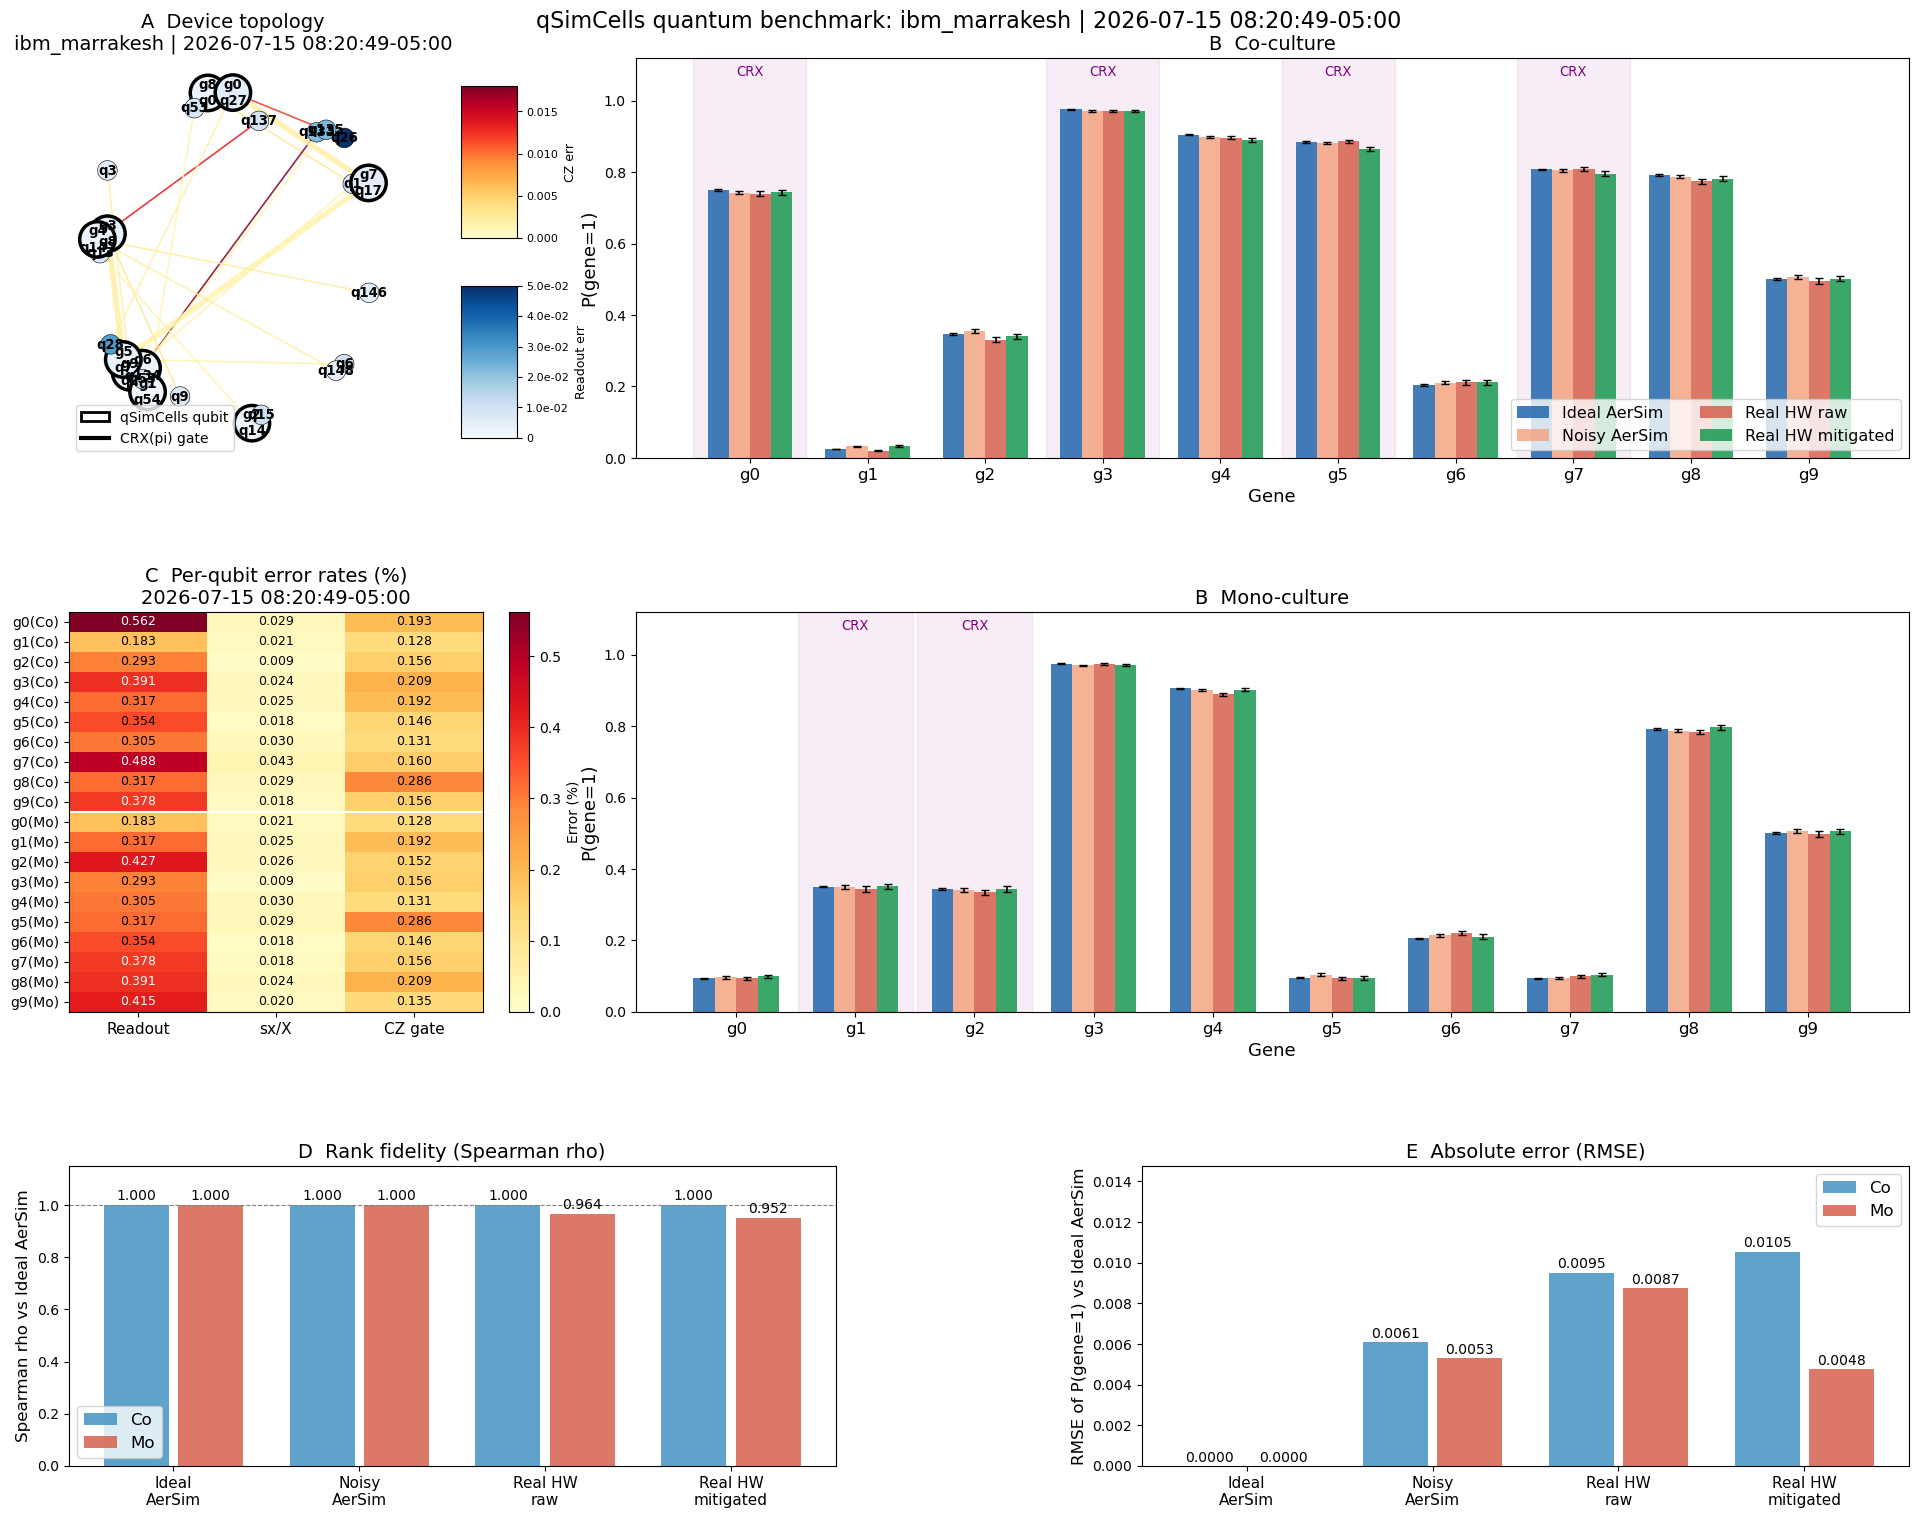

In [35]:
import matplotlib.ticker as ticker

fig = plt.figure(figsize=(20, 16), constrained_layout=False)
fig.subplots_adjust(left=0.05, right=0.97, top=0.94, bottom=0.06, hspace=0.42, wspace=0.35)

outer  = mgrid.GridSpec(3, 1, figure=fig, height_ratios=[4,4,3], hspace=0.42)
row0   = mgrid.GridSpecFromSubplotSpec(1, 10, subplot_spec=outer[0], wspace=0.35)
row1   = mgrid.GridSpecFromSubplotSpec(1, 10, subplot_spec=outer[1], wspace=0.35)
row2   = mgrid.GridSpecFromSubplotSpec(1, 2,  subplot_spec=outer[2], wspace=0.40)

ax_topo  = fig.add_subplot(row0[:2])   # 2 cols for network
ax_cbars = fig.add_subplot(row0[2])    # 1 col reserved for colorbars
ax_bco   = fig.add_subplot(row0[3:])
ax_heat  = fig.add_subplot(row1[:3])   # still 3 cols → aligns with topo+cbar
ax_bmo   = fig.add_subplot(row1[3:])
ax_rho   = fig.add_subplot(row2[0])
ax_rmse  = fig.add_subplot(row2[1])

# ── Panel A: topology ──────────────────────────────────────────────────────────
G_und = nx.Graph()
G_und.add_nodes_from(range(backend.num_qubits))
for (qa,qb) in twoq_err: G_und.add_edge(qa, qb, error=twoq_err[(qa,qb)])
used_co = set(gmap_co.values())
show    = used_co | {n for q in used_co for n in G_und.neighbors(q)}
G_sub   = G_und.subgraph(show)
pos_all = nx.spring_layout(G_und, seed=MY_SEED, k=2.5)
pos_sub = {n: pos_all[n] for n in show}
phys_to_gene = {v: f"g{k}" for k,v in gmap_co.items()}
crx_pairs    = {frozenset([gmap_co[a], gmap_co[b]]) for a,b in INTERACTION_CO}
edge_list    = list(G_sub.edges())
edge_errs    = [twoq_err.get((u,v), twoq_err.get((v,u),0.0)) for u,v in edge_list]
edge_widths  = [4.0 if frozenset([u,v]) in crx_pairs else 1.2 for u,v in edge_list]
norm_e = Normalize(vmin=0, vmax=max(edge_errs) if edge_errs else 1)
norm_r = Normalize(vmin=0, vmax=0.05)
cmap_e = cm.YlOrRd;  cmap_r = cm.Blues

nx.draw_networkx_edges(G_sub, pos_sub, edgelist=edge_list, ax=ax_topo,
    edge_color=[cmap_e(norm_e(e)) for e in edge_errs],
    width=edge_widths, alpha=0.85, arrows=False)
nx.draw_networkx_nodes(G_sub, pos_sub, ax=ax_topo,
    node_color=[cmap_r(norm_r(ro_err.get(n,0))) for n in G_sub.nodes()],
    node_size=[650 if n in used_co else 200 for n in G_sub.nodes()],
    edgecolors="black",
    linewidths=[2.5 if n in used_co else 0.4 for n in G_sub.nodes()])
nx.draw_networkx_labels(G_sub, pos_sub, ax=ax_topo,
    labels={n: (f"{phys_to_gene[n]}\nq{n}" if n in phys_to_gene else f"q{n}") for n in G_sub.nodes()},
    font_size=9.5, font_weight="bold")

ax_topo.legend(handles=[
    mpatches.Patch(facecolor="white", edgecolor="black", linewidth=2, label="qSimCells qubit"),
    plt.Line2D([0],[0], color="black", linewidth=3, label="CRX(pi) gate"),
], fontsize=10, loc="lower left")
ax_topo.set_title(f"A  Device topology\n{backend.name} | {cal_date}", fontsize=14, loc="center")
ax_topo.axis("off")

# ── Colorbars in their own dedicated column ────────────────────────────────────
ax_cbars.set_visible(False)
pos = ax_cbars.get_position()

sm_e = plt.cm.ScalarMappable(cmap=cmap_e, norm=norm_e); sm_e.set_array([])
sm_r = plt.cm.ScalarMappable(cmap=cmap_r, norm=norm_r); sm_r.set_array([])

cax_e = fig.add_axes([pos.x0 + pos.width*0.1, pos.y0 + pos.height*0.55,
                       pos.width*0.40, pos.height*0.38])
cax_r = fig.add_axes([pos.x0 + pos.width*0.1, pos.y0 + pos.height*0.05,
                       pos.width*0.40, pos.height*0.38])

cb_e = fig.colorbar(sm_e, cax=cax_e)
cb_e.set_label(f"{TWO_Q_GATE.upper()} err", fontsize=9)
cb_e.ax.tick_params(labelsize=8)

cb_r = fig.colorbar(sm_r, cax=cax_r)
cb_r.set_label("Readout err", fontsize=9)
cb_r.ax.tick_params(labelsize=8)
cb_r.ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:.1e}" if x > 0 else "0"))

# ── Panels B ───────────────────────────────────────────────────────────────────
x    = np.arange(N_GENES)
bw   = 0.18
offs = np.linspace(-(n_cond-1)/2, (n_cond-1)/2, n_cond) * bw
crx_genes_co = sorted({g for pair in INTERACTION_CO for g in pair})
crx_genes_mo = sorted({g for pair in INTERACTION_MO for g in pair})

for ax, case, title, crx_genes in [
    (ax_bco, "co", "B  Co-culture",   crx_genes_co),
    (ax_bmo, "mo", "B  Mono-culture", crx_genes_mo),
]:
    for i,(name,d) in enumerate(CONDITIONS.items()):
        p,e = d[case]
        ax.bar(x+offs[i], p, bw, label=name, color=d["color"], alpha=0.85,
               yerr=e, capsize=3, error_kw={"elinewidth":1.2,"ecolor":"black"})
    for g in crx_genes:
        ax.axvspan(g-.48, g+.48, alpha=0.07, color="purple", zorder=0)
        ax.text(g, 1.07, "CRX", ha="center", fontsize=9.5, color="purple")
    ax.set_xticks(x); ax.set_xticklabels(GENE_NAMES, fontsize=12)
    ax.set_ylabel("P(gene=1)", fontsize=13)
    ax.set_ylim(0, 1.12)
    ax.set_xlabel("Gene", fontsize=13)
    ax.set_title(title, fontsize=14, loc="center")
ax_bco.legend(fontsize=11.5, loc="lower right", ncol=2)

# ── Panel C: error heatmap ─────────────────────────────────────────────────────
metrics = ["readout_%","sx_%",f"{TWO_Q_GATE}_%"]
df_co_p = df_co_err[metrics].copy(); df_co_p.index = [f"{i}(Co)" for i in df_co_p.index]
df_mo_p = df_mo_err[metrics].copy(); df_mo_p.index = [f"{i}(Mo)" for i in df_mo_p.index]
df_heat = pd.concat([df_co_p, df_mo_p]).apply(pd.to_numeric, errors="coerce")
vals = df_heat.values.astype(float)
im = ax_heat.imshow(vals, aspect="auto", cmap="YlOrRd", vmin=0, vmax=np.nanmax(vals))
ax_heat.set_xticks(range(len(metrics)))
ax_heat.set_xticklabels(["Readout", "sx/X", f"{TWO_Q_GATE.upper()} gate"], fontsize=11)
ax_heat.set_yticks(range(len(df_heat)))
ax_heat.set_yticklabels(df_heat.index, fontsize=10)
ax_heat.axhline(N_GENES - 0.5, color="white", lw=1.5)
for r in range(vals.shape[0]):
    for c in range(vals.shape[1]):
        v = vals[r,c]
        vmax = np.nanmax(vals)
        ax_heat.text(c, r, f"{v:.3f}" if not np.isnan(v) else "---",
                     ha="center", va="center", fontsize=9,
                     color="white" if (not np.isnan(v) and v/vmax > 0.65) else "black")
plt.colorbar(im, ax=ax_heat, label="Error (%)").ax.tick_params(labelsize=10)
ax_heat.set_title(f"C  Per-qubit error rates (%)\n{cal_date}", fontsize=14, loc="center")

# ── Panel D: Spearman rho ──────────────────────────────────────────────────────
xi = np.arange(n_cond)
short = ["Ideal\nAerSim","Noisy\nAerSim","Real HW\nraw","Real HW\nmitigated"]

ax_rho.bar(xi-0.2, rho_co, 0.35, label="Co", color="#4393C3", alpha=0.85)
ax_rho.bar(xi+0.2, rho_mo, 0.35, label="Mo", color="#D6604D", alpha=0.85)
ax_rho.axhline(1.0, ls="--", lw=0.8, color="gray")
ax_rho.set_xticks(xi); ax_rho.set_xticklabels(short, fontsize=11)
ax_rho.set_ylabel("Spearman rho vs Ideal AerSim", fontsize=12)
ax_rho.set_ylim(0, 1.15)
ax_rho.set_title("D  Rank fidelity (Spearman rho)", fontsize=14, loc="center")
ax_rho.legend(fontsize=12)
for i,(rc,rm) in enumerate(zip(rho_co,rho_mo)):
    ax_rho.text(i-0.2, rc+0.02, f"{rc:.3f}", ha="center", fontsize=10)
    ax_rho.text(i+0.2, rm+0.02, f"{rm:.3f}", ha="center", fontsize=10)

# ── Panel E: RMSE ─────────────────────────────────────────────────────────────
_ymax = max(max(rmse_co), max(rmse_mo))
ax_rmse.bar(xi-0.2, rmse_co, 0.35, label="Co", color="#4393C3", alpha=0.85)
ax_rmse.bar(xi+0.2, rmse_mo, 0.35, label="Mo", color="#D6604D", alpha=0.85)
ax_rmse.set_xticks(xi); ax_rmse.set_xticklabels(short, fontsize=11)
ax_rmse.set_ylabel("RMSE of P(gene=1) vs Ideal AerSim", fontsize=12)
ax_rmse.set_ylim(0, _ymax * 1.4)
ax_rmse.set_title("E  Absolute error (RMSE)", fontsize=14, loc="center")
ax_rmse.legend(fontsize=12)
for i,(rc,rm) in enumerate(zip(rmse_co,rmse_mo)):
    ax_rmse.text(i-0.2, rc+_ymax*0.02, f"{rc:.4f}", ha="center", fontsize=10)
    ax_rmse.text(i+0.2, rm+_ymax*0.02, f"{rm:.4f}", ha="center", fontsize=10)

fig.suptitle(f"qSimCells quantum benchmark: {backend.name} | {cal_date}", fontsize=16, y=0.97)
plt.savefig("qSimCells_master_figure.pdf", dpi=200, bbox_inches="tight")
plt.savefig("qSimCells_master_figure.png", dpi=200, bbox_inches="tight")
print("Saved.")
plt.show()

## 8 · Load Existing Simulated AnnData  *(already on disk)*

In [36]:
adata_sim = ad.read_h5ad(SIM_H5AD)
print("Simulated AnnData:", adata_sim.shape)
print("Conditions:", adata_sim.obs["condition"].value_counts().to_dict())
adata_sim_co = adata_sim[adata_sim.obs["condition"] == "coculture"].copy()
adata_sim_mo = adata_sim[adata_sim.obs["condition"] == "monoculture"].copy()


Simulated AnnData: (8000, 60)
Conditions: {'monoculture': 4000, 'coculture': 4000}


## 9 · Build AnnData from Hardware Shots  *(mitigated results)*

In [37]:
try:
    from qsim_cells.generative import create_count_matrix_nbinom
    print("Using qsim_cells.generative")
except ImportError:
    def create_count_matrix_nbinom(binary_matrix, mu, r, seed=MY_SEED):
        rng = np.random.default_rng(seed)
        n_cells,n_genes = binary_matrix.shape
        counts = np.zeros((n_cells,n_genes),dtype=float)
        for j in range(n_genes):
            mask = binary_matrix[:,j].astype(bool)
            if mask.sum()>0:
                p_nb = r[j]/(r[j]+mu[j])
                counts[mask,j] = rng.negative_binomial(r[j],p_nb,size=mask.sum())
        return counts
    print("Using inline NB fallback")


Using inline NB fallback


In [38]:
def build_adata_from_hardware(pub_result, case_label, seed=MY_SEED):
    np.random.seed(seed)
    bin_ct1,bin_ct2 = sampler_to_binary_matrix(pub_result)
    n_avail = min(len(bin_ct1),len(bin_ct2))
    if n_avail < N_SHOTS:
        print(f"WARNING: {n_avail} shots < {N_SHOTS}, using all."); n=n_avail
    else:
        idx=np.random.choice(n_avail,N_SHOTS,replace=False)
        bin_ct1,bin_ct2=bin_ct1[idx],bin_ct2[idx]; n=N_SHOTS

    cm1=create_count_matrix_nbinom(bin_ct1,MU_V,R_V,seed=seed)
    cm2=create_count_matrix_nbinom(bin_ct2,MU_V,R_V,seed=seed+1)
    g1=[f"g{i}" for i in range(5)]; g2=[f"g{i+5}" for i in range(5)]
    a1=ad.AnnData(X=cm1,obs=pd.DataFrame(index=[f"hw_{i}_CT1_{case_label}" for i in range(n)]),var=pd.DataFrame(index=g1))
    a2=ad.AnnData(X=cm2,obs=pd.DataFrame(index=[f"hw_{i}_CT2_{case_label}" for i in range(n)]),var=pd.DataFrame(index=g2))
    bin_hkg=np.ones((n*2,N_HKG),dtype=int)
    cm_hkg=create_count_matrix_nbinom(bin_hkg,MU_HKG,R_HKG,seed=seed+2)
    hkg=ad.AnnData(X=cm_hkg,obs=pd.DataFrame(index=list(a1.obs_names)+list(a2.obs_names)),
                   var=pd.DataFrame(index=[f"HKG_{i}" for i in range(N_HKG)]))
    merged=ad.concat([a1,a2],axis=0,join="outer",label="BatchID",keys=[f"CT1_{case_label}",f"CT2_{case_label}"])
    merged.X[np.isnan(merged.X)]=0
    adata=ad.concat([merged,hkg],axis=1,join="inner",merge="unique")
    adata.layers["counts"]=adata.X.copy()
    sc.pp.calculate_qc_metrics(adata,inplace=True,percent_top=None)
    sc.pp.normalize_total(adata,target_sum=1e4); sc.pp.log1p(adata)
    sc.pp.scale(adata,max_value=10); sc.tl.pca(adata,svd_solver="arpack")
    sc.pp.neighbors(adata,n_neighbors=10,n_pcs=min(10,adata.n_vars))
    sc.tl.umap(adata,random_state=seed)
    sc.tl.leiden(adata,flavor="leidenalg",n_iterations=2,random_state=seed)
    adata.obs["CellType"]=adata.obs["BatchID"].map({f"CT1_{case_label}":"CellType1",f"CT2_{case_label}":"CellType2"}).astype("category")
    adata.uns["calibration_date"]=cal_date; adata.uns["backend"]=backend.name
    adata.uns["mitigation"]="DD/XY4 + gate_twirling + TREX"
    print(f"[HW {case_label}] {adata.shape} | calibration: {cal_date}")
    return adata

adata_hw_co = build_adata_from_hardware(result_mit_co[0], case_label="Co")
adata_hw_mo = build_adata_from_hardware(result_mit_mo[0], case_label="Mo")


[HW Co] (4000, 60) | calibration: 2026-07-15 08:20:49-05:00
[HW Mo] (4000, 60) | calibration: 2026-07-15 08:20:49-05:00


## 10 · Side-by-Side UMAP: Simulated vs Hardware (mitigated)

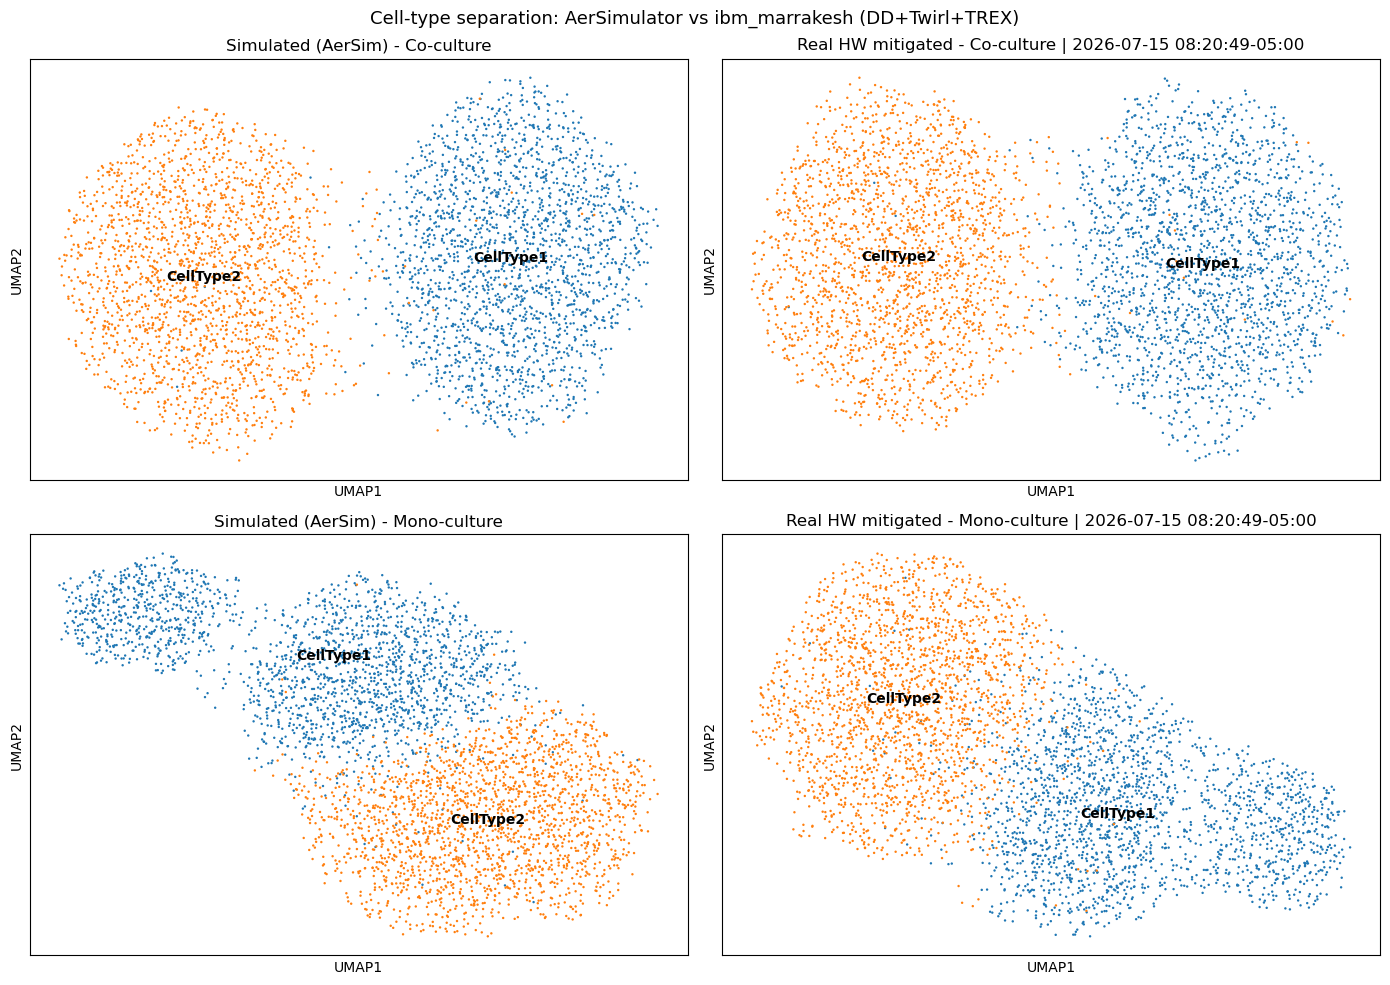

In [39]:
fig_u,axes_u = plt.subplots(2,2,figsize=(14,10))
for ax,adata_plot,title in [
    (axes_u[0,0], adata_sim_co, "Simulated (AerSim) - Co-culture"),
    (axes_u[0,1], adata_hw_co,  f"Real HW mitigated - Co-culture | {cal_date}"),
    (axes_u[1,0], adata_sim_mo, "Simulated (AerSim) - Mono-culture"),
    (axes_u[1,1], adata_hw_mo,  f"Real HW mitigated - Mono-culture | {cal_date}"),
]:
    sc.pl.umap(adata_plot,color="CellType",ax=ax,show=False,title=title,size=12,legend_loc="on data")
fig_u.suptitle(f"Cell-type separation: AerSimulator vs {backend.name} (DD+Twirl+TREX)",fontsize=13)
plt.tight_layout()
plt.savefig("fig_umap_comparison.pdf",dpi=150,bbox_inches="tight")
plt.savefig("fig_umap_comparison.png",dpi=150,bbox_inches="tight")
plt.show()


## 11 · Export: Regenerate & Save Device h5ad + JSON Report

Overwrites `sim_merged_datasets_co_mo_quantum_device_hist_corr.h5ad` with the new mitigated run.
Timestamped backup also written. JSON report captures all metadata for S4.


In [40]:
adata_hw_merged=ad.concat([adata_hw_mo,adata_hw_co],join="inner",label="condition",keys=["monoculture","coculture"])
adata_hw_merged.X=sp.csr_matrix(adata_hw_merged.layers["counts"])
adata_hw_merged.uns["calibration_date"]=cal_date; adata_hw_merged.uns["backend"]=backend.name
adata_hw_merged.uns["mitigation"]="DD/XY4 + gate_twirling + TREX"
adata_hw_merged.uns["run_date"]=str(datetime.datetime.utcnow())

adata_hw_merged.write_h5ad(str(DEV_H5AD))
print(f"Saved (overwrote): {DEV_H5AD}")
ts=datetime.datetime.utcnow().strftime("%Y%m%d")
backup_path=DATA_DIR/f"sim_merged_datasets_co_mo_quantum_device_{ts}.h5ad"
adata_hw_merged.write_h5ad(str(backup_path))
print(f"Backup: {backup_path}  |  Shape: {adata_hw_merged.shape}")


Saved (overwrote): ..\sim_merged_datasets_co_mo_quantum_device_hist_corr.h5ad
Backup: ..\sim_merged_datasets_co_mo_quantum_device_20260715.h5ad  |  Shape: (8000, 60)


In [41]:
report={
    "backend":backend.name,"calibration_date":cal_date,
    "run_utc":str(datetime.datetime.utcnow()),
    "n_qubits_device":backend.num_qubits,"native_2q_gate":TWO_Q_GATE,
    "calibration_note":(
        "IBM quantum computers undergo continuous monitoring and daily benchmarking. "
        "Error rates reflect the calibration snapshot at run time. "
        "T1/T2 and gate fidelities drift due to TLS fluctuations, ambient conditions, "
        "and control-system instability. The calibration_date field uniquely identifies "
        "the snapshot used for this run."),
    "device_medians":{
        "T1_us":round(np.nanmedian(list(t1_us.values())),1),
        "T2_us":round(np.nanmedian(list(t2_us.values())),1),
        "readout_pct":round(np.nanmedian(list(ro_err.values()))*100,3),
        "sx_pct":round(np.nanmedian(list(sx_err.values()))*100,4),
        f"{TWO_Q_GATE}_pct":round(np.nanmedian(list(twoq_err.values()))*100,3)},
    "co_gene_map":{f"g{g}":int(q) for g,q in gmap_co.items()},
    "mo_gene_map":{f"g{g}":int(q) for g,q in gmap_mo.items()},
    "shot_budgets":{"sim_ideal":SIM_SHOTS,"sim_noisy":NOISE_SIM_SHOTS,
        "hw_raw":RAW_SHOTS,"hw_mitigated":NUM_RANDS*SHOTS_PER_RAND,
        "num_rands":NUM_RANDS,"shots_per_rand":SHOTS_PER_RAND,"cells_per_adata":N_SHOTS},
    "mitigation":["DD/XY4","gate_twirling","TREX"],
    "benchmark":{
        "metric_1":"Spearman rho of per-gene P(1) vs Ideal AerSim",
        "metric_2":"RMSE of per-gene P(1) vs Ideal AerSim",
        "metric_3":"Spearman rho of full joint 2^10 histogram vs Ideal AerSim",
        "results":{name:{"spearman_rho_co":round(rho_co[i],4),"spearman_rho_mo":round(rho_mo[i],4),
                          "rmse_co":round(rmse_co[i],6),"rmse_mo":round(rmse_mo[i],6),"joint_rho_co":round(rho_joint_co[i],4),"joint_rho_mo":round(rho_joint_mo[i],4)}
                   for i,name in enumerate(cond_names)}},
    "adata_files":{"simulated":str(SIM_H5AD),"device":str(DEV_H5AD),"backup":str(backup_path)},
}
with open("hardware_report_hist_corr.json","w") as f: json.dump(report,f,indent=2)
print(json.dumps(report,indent=2))


{
  "backend": "ibm_marrakesh",
  "calibration_date": "2026-07-15 08:20:49-05:00",
  "run_utc": "2026-07-15 20:47:50.694233",
  "n_qubits_device": 156,
  "native_2q_gate": "cz",
  "calibration_note": "IBM quantum computers undergo continuous monitoring and daily benchmarking. Error rates reflect the calibration snapshot at run time. T1/T2 and gate fidelities drift due to TLS fluctuations, ambient conditions, and control-system instability. The calibration_date field uniquely identifies the snapshot used for this run.",
  "device_medians": {
    "T1_us": 149.4,
    "T2_us": 82.5,
    "readout_pct": 1.038,
    "sx_pct": 0.0326,
    "cz_pct": 0.286
  },
  "co_gene_map": {
    "g0": 27,
    "g1": 54,
    "g2": 14,
    "g3": 8,
    "g4": 147,
    "g5": 7,
    "g6": 134,
    "g7": 17,
    "g8": 0,
    "g9": 2
  },
  "mo_gene_map": {
    "g0": 54,
    "g1": 147,
    "g2": 148,
    "g3": 14,
    "g4": 134,
    "g5": 0,
    "g6": 7,
    "g7": 2,
    "g8": 8,
    "g9": 19
  },
  "shot_budgets": 

---
## 12 · Standalone: Joint Histogram Distribution Test

Run these cells independently (after IBM authentication and circuit build, OR after
loading `joint_histograms_hist_corr.npz` from a previous run) to validate the full 2^10 joint
distribution against the ideal AerSim reference.

**Option A** — Load from saved `.npz` (no IBM connection needed):
run *Cell 12-A* then *Cell 12-C*.

**Option B** — Load directly from IBM job IDs (requires `service`, `qc_co`, `qc_mo`,
`noise_model` already defined from the main notebook):
run *Cell 12-B* then *Cell 12-C*.


In [43]:
# ── Cell 12-A: Load from saved joint_histograms_hist_corr.npz ─────────────────────────
import numpy as np
from scipy.stats import spearmanr
from scipy.spatial.distance import jensenshannon
from scipy.stats import ks_2samp

_d = np.load("joint_histograms_hist_corr.npz")
jp_ideal_co = _d["jp_ideal_co"]
jp_ideal_mo = _d["jp_ideal_mo"]
jp_noisy_co = _d["jp_noisy_co"]
jp_noisy_mo = _d["jp_noisy_mo"]
jp_raw_co   = _d["jp_raw_co"]
jp_raw_mo   = _d["jp_raw_mo"]
jp_mit_co   = _d["jp_mit_co"]
jp_mit_mo   = _d["jp_mit_mo"]

cond_names = ["Ideal AerSim", "Noisy AerSim", "Real HW raw", "Real HW mitigated"]
JOINT_DATA = {
    "Ideal AerSim"     : (jp_ideal_co, jp_ideal_mo),
    "Noisy AerSim"     : (jp_noisy_co, jp_noisy_mo),
    "Real HW raw"      : (jp_raw_co,   jp_raw_mo),
    "Real HW mitigated": (jp_mit_co,   jp_mit_mo),
}
print("Loaded joint_histograms_hist_corr.npz — ready for Cell 12-C")

Loaded joint_histograms_hist_corr.npz — ready for Cell 12-C


In [46]:
# ── Cell 12-B: Distribution tests (run after 12-A) ──────────────────
from scipy.stats import spearmanr, ks_2samp
from scipy.spatial.distance import jensenshannon
import numpy as np

print("=" * 72)
print(f"{'Condition':<25} {'Spearman rho':>12} {'JS div':>8} {'KS stat':>9} {'KS p':>10} {'TV':>8}")
print("-" * 72)

results = {}
for name in cond_names:
    jco, jmo = JOINT_DATA[name]
    rho_co = spearmanr(jp_ideal_co, jco).statistic
    js_co  = jensenshannon(jp_ideal_co, jco, base=2)
    ks_co  = ks_2samp(jp_ideal_co, jco)
    tv_co  = np.sum(np.abs(jp_ideal_co - jco)) / 2
    rho_mo = spearmanr(jp_ideal_mo, jmo).statistic
    js_mo  = jensenshannon(jp_ideal_mo, jmo, base=2)
    ks_mo  = ks_2samp(jp_ideal_mo, jmo)
    tv_mo  = np.sum(np.abs(jp_ideal_mo - jmo)) / 2
    results[name] = dict(rho_co=rho_co, js_co=js_co, ks_co=ks_co.statistic,
                         ksp_co=ks_co.pvalue, tv_co=tv_co,
                         rho_mo=rho_mo, js_mo=js_mo, ks_mo=ks_mo.statistic,
                         ksp_mo=ks_mo.pvalue, tv_mo=tv_mo)
    print(f"  Co  {name:<21} {rho_co:>12.4f} {js_co:>8.4f} {ks_co.statistic:>9.4f} {ks_co.pvalue:>10.4f} {tv_co:>8.4f}")
    print(f"  Mo  {name:<21} {rho_mo:>12.4f} {js_mo:>8.4f} {ks_mo.statistic:>9.4f} {ks_mo.pvalue:>10.4f} {tv_mo:>8.4f}")
    print()

print("=" * 72)
print()
print("Key: Spearman rho > 0.95 = strong rank-order agreement over 1024 outcomes")
print("     JS div < 0.05 = distributions nearly identical; TV < 0.05 = < 5% mass diff")
print()
print(f"Real HW raw vs Ideal: Co rho={results['Real HW raw']['rho_co']:.4f}, Mo rho={results['Real HW raw']['rho_mo']:.4f}")

assert results["Ideal AerSim"]["rho_co"] > 0.9999, "Self-check failed (Co)!"
assert results["Ideal AerSim"]["rho_mo"] > 0.9999, "Self-check failed (Mo)!"
print("Self-check passed.")


Condition                 Spearman rho   JS div   KS stat       KS p       TV
------------------------------------------------------------------------
  Co  Ideal AerSim                1.0000   0.0000    0.0000     1.0000   0.0000
  Mo  Ideal AerSim                1.0000   0.0000    0.0000     1.0000   0.0000

  Co  Noisy AerSim                0.8090   0.1210    0.1045     0.0000   0.0612
  Mo  Noisy AerSim                0.7920   0.1111    0.0928     0.0003   0.0544

  Co  Real HW raw                 0.7418   0.1471    0.1787     0.0000   0.0786
  Mo  Real HW raw                 0.7704   0.1467    0.1592     0.0000   0.0881

  Co  Real HW mitigated           0.7517   0.1613    0.1553     0.0000   0.0907
  Mo  Real HW mitigated           0.7516   0.1399    0.1592     0.0000   0.0737


Key: Spearman rho > 0.95 = strong rank-order agreement over 1024 outcomes
     JS div < 0.05 = distributions nearly identical; TV < 0.05 = < 5% mass diff

Real HW raw vs Ideal: Co rho=0.7418, Mo rho=0.770

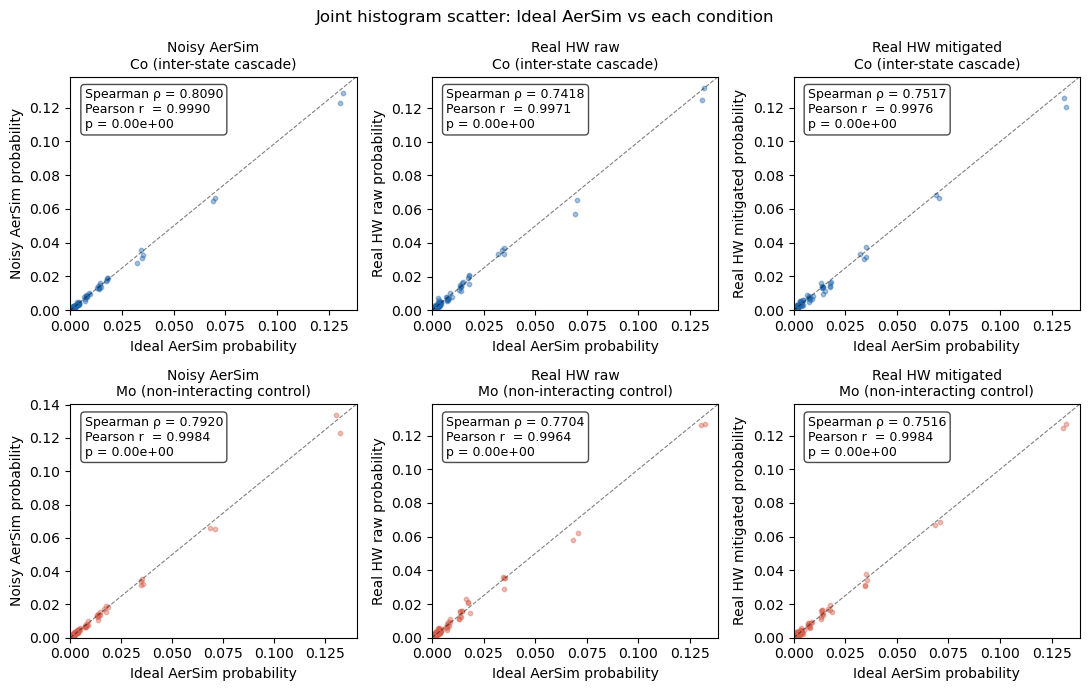

In [52]:
from scipy.stats import spearmanr, pearsonr

conditions = ["Noisy AerSim", "Real HW raw", "Real HW mitigated"]
fig, axes = plt.subplots(2, 3, figsize=(11, 7))
fig.suptitle("Joint histogram scatter: Ideal AerSim vs each condition", fontsize=12)

for col, name in enumerate(conditions):
    for row, (ref, label) in enumerate([
        (jp_ideal_co, "Co (inter-state cascade)"),
        (jp_ideal_mo, "Mo (non-interacting control)")
    ]):
        ax = axes[row, col]
        jp_cond = JOINT_DATA[name][row]
        rho = spearmanr(ref, jp_cond).statistic
        r, p_r = pearsonr(ref, jp_cond)

        ax.scatter(ref, jp_cond, alpha=0.4, s=10,
                   color="#2166AC" if row == 0 else "#D6604D")
        lim = max(ref.max(), jp_cond.max()) * 1.05
        ax.plot([0, lim], [0, lim], "k--", lw=0.8, alpha=0.5)
        ax.set_xlim(0, lim); ax.set_ylim(0, lim)
        ax.set_xlabel("Ideal AerSim probability", fontsize=10)
        ax.set_ylabel(f"{name} probability", fontsize=10)
        ax.set_title(f"{name}\n{label}", fontsize=10)
        ax.text(0.05, 0.95,
                f"Spearman ρ = {rho:.4f}\nPearson r  = {r:.4f}\np = {p_r:.2e}",
                transform=ax.transAxes, fontsize=9,
                verticalalignment='top',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

plt.tight_layout()
plt.savefig("qsimcells_figs4.pdf", dpi=200, bbox_inches="tight")
#plt.savefig("joint_histogram_scatter.png", dpi=200, bbox_inches="tight")
plt.show()